# 逻辑回归（Logistic Regression）

逻辑回归（Logistic Regression）是一种广泛应用于分类问题的统计学习方法，尽管名字中带有"回归"，但它实际上是一种用于二分类或多分类问题的算法。

逻辑回归通过使用逻辑函数（也称为 Sigmoid 函数）将线性回归的输出映射到 0 和 1 之间，从而预测某个事件发生的概率。

逻辑回归广泛应用于各种分类问题，例如：

- 垃圾邮件检测（是垃圾邮件/不是垃圾邮件）
- 疾病预测（患病/不患病）
- 客户流失预测（流失/不流失）

逻辑回归的目标是预测一个二分类结果：

$$
p(y=1|X) = \sigma(w^T X + b)
$$

- $X$ 是输入特征
- $w$ 是权重向量
- $b$ 是偏置项
- $\sigma(z) = \frac{1}{1 + e^{-z}}$ 是 Sigmoid 函数，这个函数可以将输入映射到 0 到 1 之间，可以看作是属于 1 的概率

损失函数是对数损失函数（Log loss）：
$$
J(w,b) = -\frac 1 m \sum_{i=1}^m [ y^{(i)}\text{log}(h(x^{(i)}))  + (1 - y^{i}) \text{log}(1 - h(x^{(i)}))]
$$

- $m$ 是训练样本数量
- $h(x) = \sigma (w^T x = b)$ 是逻辑回归的预测概率

## 使用 Python 实现逻辑回归

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

我们将使用 Scikit-learn 自带的 Iris 数据集。Iris 数据集包含 150 个样本，每个样本有 4 个特征，目标是将样本分为 3 类。为了简化问题，我们只使用前两个特征，并将问题转化为二分类问题。

In [3]:
# 加载数据集
iris = load_iris()
X = iris.data[:, :2]  # 只使用前两个特征
y = (iris.target != 0) * 1  # 将目标转化为二分类问题

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

3、训练逻辑回归模型

In [4]:
# 创建逻辑回归模型
model = LogisticRegression()

# 训练模型
model.fit(X_train, y_train, )

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 加载数据集
iris = load_iris()
X = iris.data[:, :2]  # 只使用前两个特征
y = (iris.target != 0) * 1  # 将目标转化为二分类问题

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# 创建逻辑回归模型
model = LogisticRegression()

# 训练模型
model.fit(X_train, y_train)

# 预测测试集
y_pred = model.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy:.2f}")

# 混淆矩阵
conf_matrix = confusion_matrix(y_test, y_pred)
print("混淆矩阵:")
print(conf_matrix)

# 分类报告
class_report = classification_report(y_test, y_pred)
print("分类报告:")
print(class_report)

模型准确率: 1.00
混淆矩阵:
[[19  0]
 [ 0 26]]
分类报告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        26

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



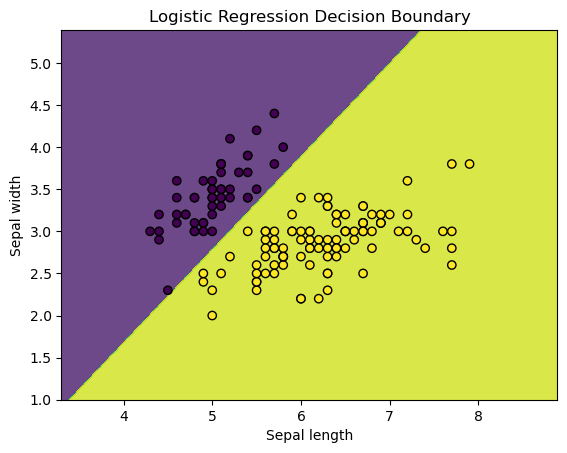

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 加载数据集
iris = load_iris()
X = iris.data[:, :2]  # 只使用前两个特征
y = (iris.target != 0) * 1  # 将目标转化为二分类问题

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# 创建逻辑回归模型
model = LogisticRegression()

# 训练模型
model.fit(X_train, y_train)

# 预测测试集
y_pred = model.predict(X_test)

# 可视化决策边界
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Logistic Regression Decision Boundary')
plt.show()

## 手写实现

求导：
$$
\frac{\partial y_{pred}}{\partial z} = \sigma (1 - \sigma) = \frac{1}{1+e^{-z}} (1 - \frac{1}{1+e^{-z}}) 

=  \frac{1}{1+e^{-z}}   \frac{e^{-z}}{1 + e^{-z}} = \frac{1}{}
$$

损失函数定义：
$$
J = - [ y \ln (y_{pred}) + (1-y)\ln(1 - y_{pred})  ]
$$

# 